# 14 – Kennlinienmonitor: jede Station gegen sich selbst

Ausgangslage:

- Die Kennliniensteigung aus Notebook 13 ordnet die Stationen gut (Faktor 3,7 zwischen flachen und steilen Kennlinien).
- Ein Klassifikator wird daraus trotzdem nicht. Notebook 01, 04 und der ML-Ansatz haben gezeigt: zu wenige und zu unsaubere Labels, und der Vergleich zwischen Stationen mischt Gebäudegröße, Heizung und Fahrweise.

Idee hier:

- nicht Stationen untereinander vergleichen, sondern jede Station mit sich selbst
- die Kennlinie ist das Modell: bleibt die Station auf ihrer Geraden, ist alles gut. Verschiebt sich die Gerade, ist etwas passiert.
- Labels braucht das nicht. Die Begehungstermine dienen nur zur Gegenprobe.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import kennlinien_monitor as km
from src import load_begehungen as lb
from src import stationsbilder as sb
from src import ternaer as tn

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 30)

METER_DIR = ROOT / "data" / "processed" / "real_meters"

#68956351 ist der einzige Fall, bei dem wir aus den Daten wissen, was
#passiert ist: das Ventil stand drei Jahre offen, im September 2024
#wurde es repariert. Der Ventiltausch steht nur im Freitext der
#Begehung vom 09.09.2024, nicht in den Alt/Neu-Spalten (Notebook 15).
BEISPIEL = 68956351
BEISPIEL_DATUM = pd.Timestamp("2024-09-09")

t0 = time.time()
serien = tn.lade_serien(METER_DIR)
roh = lb.begehung_dates_by_meter()
termine = {int(k): list(v) for k, v in roh.items()}
print(f"{len(serien)} Zaehlerreihen in {time.time() - t0:.0f} s")
print(f"{len(termine)} Zaehler mit Begehungsdatum, "
      f"{sum(len(v) for v in termine.values())} Termine")

100 Zaehlerreihen in 15 s
56 Zaehler mit Begehungsdatum, 58 Termine


## 1 Zwei Kanäle

**Parameterkanal:**

- gleitendes Fenster, Kennlinie wird in jedem Fenster neu gefittet
- verfolgt die Steigung über die Zeit
- sieht Änderungen der Regelung, z. B. ein Ventil, das sich nicht mehr bewegt (Steigung geht gegen null)

**Residuenkanal:**

- eine feste Kennlinie über die ganze Historie
- misst je Stunde, wie weit der Durchfluss von der Geraden abweicht
- sieht Niveauverschiebungen: die Station regelt noch, aber auf einem anderen Arbeitspunkt

**Alarm:** Für beide Kanäle vergleicht ein Sprungscore die nächsten vorhandenen Werte links und rechts eines Tages (normierte Differenz der Mediane). Über der Schwelle und ohne größeren Nachbarn gibt es einen Alarm.

Vorteil der Kennlinie: sie hängt nicht vom Wetter ab. Sie zeigt, wie die Station regelt, nicht wie viel geheizt wird.

In [2]:
print("Parameterkanal")
print(f"  Fensterbreite {km.FENSTER_TAGE} Tage, Schritt {km.SCHRITT_TAGE} Tag")
print(f"  gedehnt bis hoechstens {km.MAX_FENSTER_TAGE} Tage, "
      f"wenn {km.MIN_PUNKTE} Punkte sonst nicht zusammenkommen")
print("Residuenkanal")
print(f"  Referenzfit ueber die ganze Historie, Tagesmedian ab "
      f"{km.MIN_STUNDEN_TAG} Betriebsstunden")
print("Alarme")
print(f"  Schwelle {km.ALARM_SCHWELLE}, Mindestabstand "
      f"{km.MINDESTABSTAND_TAGE} Tage")
print(f"  Treffer gilt bei hoechstens {km.TOLERANZ_TAGE} Tagen Abstand "
      f"zum Begehungstermin")

Parameterkanal
  Fensterbreite 14 Tage, Schritt 1 Tag
  gedehnt bis hoechstens 60 Tage, wenn 30 Punkte sonst nicht zusammenkommen
Residuenkanal
  Referenzfit ueber die ganze Historie, Tagesmedian ab 3 Betriebsstunden
Alarme
  Schwelle 3.0, Mindestabstand 30 Tage
  Treffer gilt bei hoechstens 30 Tagen Abstand zum Begehungstermin


## 2 Der einzige Fall, den wir kennen

Zähler 68956351:

- Ventil stand über Jahre offen, Rücklauf dauerhaft warm
- im September 2024 repariert (Begehung am 09.09.2024)
- der Ventiltausch steht nur im Freitext, nicht in den Alt-Neu-Spalten (siehe Notebook 15)

Hier muss der Monitor anschlagen.

In [3]:
t1 = time.time()
e_bsp = km.monitor_station(serien[BEISPIEL], BEISPIEL)
print(f"monitor_station in {time.time() - t1:.1f} s")
print(e_bsp["abdeckung"].to_string(index=False))

al = e_bsp["alarme"]
print(f"\n{len(al)} Alarme insgesamt")
print(al.sort_values("score", key=lambda s: s.abs(), ascending=False)
        .head(8).to_string(index=False))

monitor_station in 2.0 s
   meter erster_tag letzter_tag  tage  referenz_n  referenz_steigung
68956351 2021-11-04  2025-07-11  1346       10281          -0.004816

16 Alarme insgesamt
   meter    quelle        kennzahl      datum      score richtung
68956351 parameter        steigung 2024-09-12  73.955304     hoch
68956351 parameter        steigung 2025-06-09 -49.656466   runter
68956351 parameter        steigung 2025-05-10 -16.347521   runter
68956351  residuum residuum_median 2024-10-01 -14.631956   runter
68956351  residuum residuum_median 2025-04-26   7.716971     hoch
68956351 parameter        steigung 2024-01-10  -7.544192   runter
68956351 parameter        steigung 2024-12-10   5.805032     hoch
68956351  residuum residuum_median 2024-01-09  -5.432303   runter


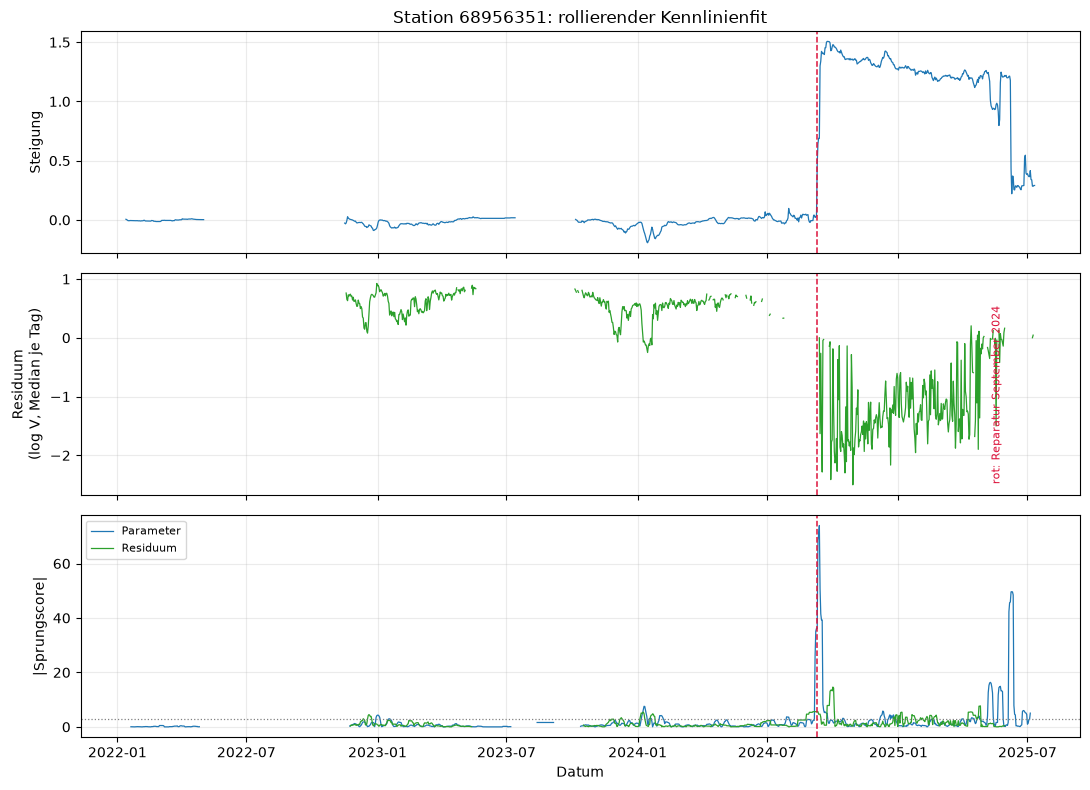

In [4]:
f = e_bsp["fenster"].copy()
f["score"] = km.sprungscore(f["steigung"].to_numpy(dtype=float))
r = e_bsp["residuum"].copy()
r["score"] = km.sprungscore(r["residuum_median"].to_numpy(dtype=float))

fig, ax = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
ax[0].plot(f["datum"], f["steigung"], lw=0.9, color="#1f77b4")
ax[0].set_ylabel("Steigung")
ax[0].set_title(f"Station {BEISPIEL}: rollierender Kennlinienfit")
ax[1].plot(r["datum"], r["residuum_median"], lw=0.9, color="#2ca02c")
ax[1].set_ylabel("Residuum\n(log V, Median je Tag)")
ax[2].plot(f["datum"], f["score"].abs(), lw=0.9, color="#1f77b4",
           label="Parameter")
ax[2].plot(r["datum"], r["score"].abs(), lw=0.9, color="#2ca02c",
           label="Residuum")
ax[2].axhline(km.ALARM_SCHWELLE, color="grey", ls=":", lw=0.9)
ax[2].set_ylabel("|Sprungscore|")
ax[2].legend(loc="upper left", fontsize=8)
for a in ax:
    a.axvline(BEISPIEL_DATUM, color="crimson", ls="--", lw=1.1)
    a.grid(alpha=0.25)
ax[2].set_xlabel("Datum")
fig.text(0.905, 0.5, "rot: Reparatur September 2024", rotation=90,
         va="center", fontsize=8, color="crimson")
fig.tight_layout()
plt.show()

In [5]:
nah = al[(al["datum"] >= BEISPIEL_DATUM - pd.Timedelta(days=45)) &
         (al["datum"] <= BEISPIEL_DATUM + pd.Timedelta(days=45))]
print("Alarme im Umfeld der Reparatur:")
print(nah.to_string(index=False) if len(nah) else "keine")

rest = al[~al.index.isin(nah.index)]
print(f"\nalle uebrigen Alarme: |Score| von "
      f"{rest['score'].abs().min():.1f} bis {rest['score'].abs().max():.1f}")

Alarme im Umfeld der Reparatur:
   meter    quelle        kennzahl      datum      score richtung
68956351 parameter        steigung 2024-07-28   3.674605     hoch
68956351 parameter        steigung 2024-09-12  73.955304     hoch
68956351 parameter        steigung 2024-10-15  -3.160425   runter
68956351  residuum residuum_median 2024-09-01  -5.339846   runter
68956351  residuum residuum_median 2024-10-01 -14.631956   runter

alle uebrigen Alarme: |Score| von 3.4 bis 49.7


- **Parameterkanal:** Alarm drei Tage nach dem Termin mit Betrag rund 74. Das ist der größte Ausschlag in der ganzen Historie der Station.
- **Residuenkanal:** Alarme auf beiden Seiten des Termins, am 1. September (−5,3) und am 1. Oktober (−14,6).
- Die Referenzkennlinie hat eine Steigung von praktisch null, passend zum offenen Ventil.
- Zweitgrößter Alarm: knapp 50 im Juni 2025. Wofür der steht, wissen wir nicht. Ein hoher Score heißt also nicht automatisch Begehung oder Defekt.

Der Mechanismus funktioniert. Ob er auch bei kleineren Veränderungen anschlägt, zeigt Abschnitt 5.

## 3 Warum ein starres Fenster im Sommer blind ist

Der erste Durchlauf hat den Fall nicht gefunden:

- im Hochsommer läuft die Station nur wenige Stunden am Tag
- ein 14-Tage-Fenster hat dann zu wenige Punkte für den Fit und bleibt leer
- die Lücke lag genau vor dem Termin, dem Sprungscore fehlte die Vorher-Seite

In [6]:
tab = sb.punkttabelle(serien[BEISPIEL], BEISPIEL, aufloesung="stunde")
betrieb = tab[(tab["power_kw"] > 0) & (tab["flow_lh"] > 0) &
              (tab["dt_k"] > 0)].copy()
betrieb["monat"] = pd.to_datetime(betrieb["zeit"]).dt.to_period("M")
je_monat = betrieb.groupby("monat").size()
print("Betriebsstunden je Monat, Mai bis Oktober 2024:")
print(je_monat[je_monat.index >= pd.Period("2024-05")].head(6).to_string())
print(f"\nzum Vergleich Januar 2024: {je_monat.get(pd.Period('2024-01'), 0)}")

Betriebsstunden je Monat, Mai bis Oktober 2024:
monat
2024-05    101
2024-06     87
2024-07     57
2024-08     61
2024-09    109
2024-10    310
Freq: M

zum Vergleich Januar 2024: 668


Fenster Jul bis Sep 2024: 92, davon ohne Fit: 0
Fensterbreite dort: Median 15, Maximum 19 Tage

ueber die ganze Historie gedehnt (> 14 Tage): 0.389 der Fenster
mittlere Fensterbreite je Kalendermonat:
monat
1     24.7
2     22.8
3     22.3
4     23.4
5     25.4
6     30.7
7     33.8
8     25.7
9     26.3
10    21.9
11    21.2
12    21.2


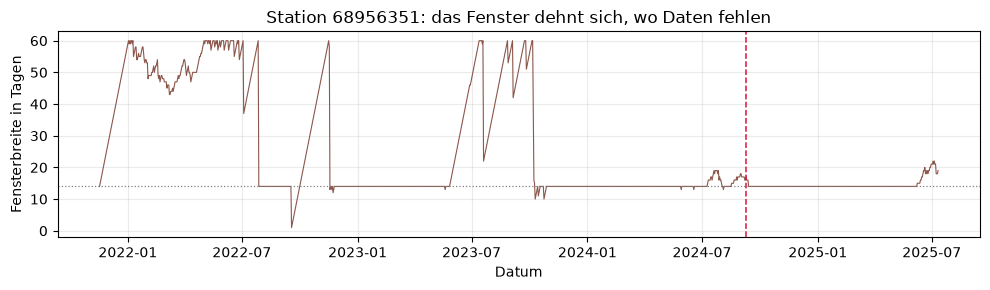

In [7]:
sommer = f[(f["datum"] >= "2024-07-01") & (f["datum"] <= "2024-09-30")]
print(f"Fenster Jul bis Sep 2024: {len(sommer)}, "
      f"davon ohne Fit: {int(sommer['steigung'].isna().sum())}")
print(f"Fensterbreite dort: Median {sommer['breite_tage'].median():.0f}, "
      f"Maximum {sommer['breite_tage'].max():.0f} Tage")

print(f"\nueber die ganze Historie gedehnt (> {km.FENSTER_TAGE} Tage): "
      f"{(f['breite_tage'] > km.FENSTER_TAGE).mean():.3f} der Fenster")
je_monat_breite = (f.assign(monat=pd.to_datetime(f["datum"]).dt.month)
                   .groupby("monat")["breite_tage"].mean().round(1))
print("mittlere Fensterbreite je Kalendermonat:")
print(je_monat_breite.to_string())

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(f["datum"], f["breite_tage"], lw=0.8, color="#8c564b")
ax.axhline(km.FENSTER_TAGE, color="grey", ls=":", lw=0.9)
ax.axvline(BEISPIEL_DATUM, color="crimson", ls="--", lw=1.1)
ax.set_ylabel("Fensterbreite in Tagen")
ax.set_xlabel("Datum")
ax.set_title(f"Station {BEISPIEL}: das Fenster dehnt sich, wo Daten fehlen")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

**Lösung: Fenster dehnt sich, wenn zu wenige Punkte da sind.**

- Juli im Mittel 34 Tage, November 21 Tage
- gut ein Drittel aller Fenster ist gedehnt, maximal bis 60 Tage
- im Sommer 2024 reichen bis zu 19 Tage, damit hat keines der 92 Fenster zwischen Juli und September eine Lücke
- Nachteil: ein Sprung im Sommer wird zeitlich ungenauer datiert als im Winter

**Sprungscore:** vergleicht aus demselben Grund die nächsten vorhandenen Werte links und rechts (mit maximalem Abstand) statt eines festen Zeitfensters.

## 4 Lauf über alle Stationen

Gleiche Parameter für alle, nichts wird je Station nachjustiert.

In [8]:
t2 = time.time()
erg = km.monitor_alle(serien, fortschritt=False)
print(f"Vollauf in {time.time() - t2:.0f} s")
print({k: len(v) for k, v in erg.items()})

alarme = erg["alarme"]
abdeckung = erg["abdeckung"]
print("\nAlarme je Kanal:")
print(alarme.groupby("quelle").size().to_string())
print("\nAlarme je Station und Kanal:")
print(alarme.groupby(["quelle", "meter"]).size()
      .groupby("quelle").describe().round(2).to_string())

Vollauf in 67 s
{'fenster': 84486, 'residuum': 85708, 'alarme': 1099, 'abdeckung': 100}

Alarme je Kanal:
quelle
parameter    629
residuum     470

Alarme je Station und Kanal:
           count  mean   std  min  25%  50%  75%   max
quelle                                                
parameter   94.0  6.69  3.28  1.0  4.0  6.5  9.0  14.0
residuum    90.0  5.22  2.60  1.0  3.0  5.0  7.0  11.0


1099 Alarme auf 235 Stationsjahren, also rund 4.7 Alarme je Station und Jahr


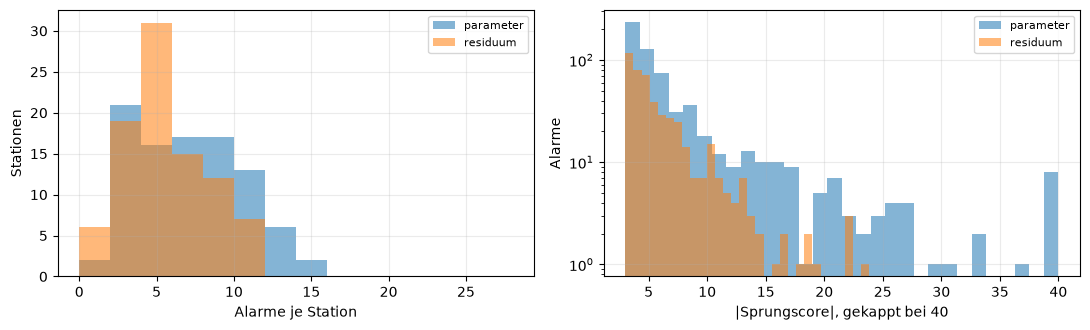

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for i, q in enumerate(sorted(alarme["quelle"].unique())):
    teil = alarme[alarme["quelle"] == q]
    je_station = teil.groupby("meter").size()
    ax[0].hist(je_station, bins=range(0, 30, 2), alpha=0.55, label=q)
    ax[1].hist(teil["score"].abs().clip(upper=40), bins=30, alpha=0.55,
               label=q)
ax[0].set_xlabel("Alarme je Station")
ax[0].set_ylabel("Stationen")
ax[0].legend(fontsize=8)
ax[1].set_xlabel("|Sprungscore|, gekappt bei 40")
ax[1].set_ylabel("Alarme")
ax[1].set_yscale("log")
ax[1].legend(fontsize=8)
for a in ax:
    a.grid(alpha=0.25)
fig.tight_layout()
plt.show()

jahre = abdeckung["tage"].sum() / 365.25
print(f"{len(alarme)} Alarme auf {jahre:.0f} Stationsjahren, "
      f"also rund {len(alarme) / jahre:.1f} Alarme je Station und Jahr")

- Knapp fünf Alarme je Station und Jahr über beide Kanäle, also gut zwei je Kanal.
- Für eine Vorsortierung von 100 Stationen machbar. Ob das im Betrieb tragbar ist, muss die ÜZ sagen.

## 5 Gegenprobe gegen die Begehungstermine

Frage: Liegt öfter als zufällig ein Alarm in der Nähe eines Begehungstermins?

Wichtig ist die Zufallsbasis: Eine Station mit vielen Alarmen trifft fast jeden Termin. Deshalb wird je Station berechnet, welche Trefferquote allein aus Alarmzahl und Historienlänge folgt.

In [10]:
beobachtet = set(abdeckung["meter"].astype(int))
termine_b = {m: t for m, t in termine.items() if m in beobachtet}
print(f"{len(termine_b)} Begehungsstationen mit Monitorhistorie, "
      f"{sum(len(v) for v in termine_b.values())} Faelle")

pruef = km.validiere(alarme, termine_b)
quote = km.trefferquote(pruef)
basis = km.zufallsbasis(alarme, abdeckung, termine_b)
vergleich = quote.merge(basis, on=["quelle", "kennzahl"], how="left")
vergleich["hebel"] = (vergleich["quote"] /
                      vergleich["erwartete_quote"]).round(2)
vergleich["p"] = [
    round(float(stats.binomtest(int(r["treffer"]), int(r["faelle"]),
                                float(r["erwartete_quote"]),
                                alternative="greater").pvalue), 4)
    for _, r in vergleich.iterrows()]
print()
print(vergleich.round(3).to_string(index=False))

51 Begehungsstationen mit Monitorhistorie, 53 Faelle

   quelle        kennzahl  faelle  treffer  quote  median_abstand_tage  stationen  alarme_je_station  erwartete_quote  hebel     p
parameter        steigung      53       25  0.472                  8.0         51              6.353            0.371   1.27 0.085
 residuum residuum_median      53       20  0.377                  9.0         51              4.725            0.287   1.31 0.099


In [11]:
tr = pruef[pruef["treffer"]]
print("Abstand der Treffer zum Begehungstermin, in Tagen:")
print(tr.groupby("quelle")["abstand_tage"].describe().round(1).to_string())

Abstand der Treffer zum Begehungstermin, in Tagen:
           count  mean   std   min  25%  50%   75%   max
quelle                                                  
parameter   25.0   2.0  13.2 -29.0 -4.0  3.0  12.0  27.0
residuum    20.0   2.6  11.8 -19.0 -8.0  5.0   9.2  24.0


- Beide Kanäle liegen über der Zufallsbasis, Hebel ca. 1,3.
- Die Richtung stimmt, aber bei rund 50 Fällen ist das kein Nachweis.
- Die Treffer liegen nicht genau auf dem Termin, sondern im Median etwa eine Woche entfernt. Das kann eine verzögerte Wirkung sein, aber genauso Zufall.

## 6 Hängt das Ergebnis an der Schwelle?

Wenn im Sprungscore echte Information steckt, sollte der Hebel steigen, wenn man nur die stärksten Ausschläge nimmt. Geprüft über verschiedene Schwellen und über die stärksten Alarme je Station.

In [12]:
fenster_all = erg["fenster"]
resid_all = erg["residuum"]
KANAELE = [(km.QUELLE_PARAMETER, "steigung", fenster_all, "score_steigung"),
           (km.QUELLE_RESIDUUM, "residuum_median", resid_all,
            "score_residuum")]


def baue(schwelle, topk=None):
    teile = []
    for quelle, kennzahl, frame, spalte in KANAELE:
        for meter, teil in frame.groupby("meter"):
            a = km.alarme(teil["datum"], teil[spalte], schwelle=schwelle)
            if not len(a):
                continue
            if topk is not None:
                a = a.reindex(a["score"].abs().sort_values(ascending=False)
                              .index).head(topk)
            teile.append(a.assign(meter=int(meter), quelle=quelle,
                                  kennzahl=kennzahl))
    return pd.concat(teile, ignore_index=True) if teile else pd.DataFrame()


zeilen = []
for schwelle, topk in [(3.0, None), (4.0, None), (5.0, None), (6.0, None),
                       (8.0, None), (3.0, 3), (3.0, 2), (3.0, 1)]:
    al_s = baue(schwelle, topk)
    z = (km.trefferquote(km.validiere(al_s, termine_b))
         .merge(km.zufallsbasis(al_s, abdeckung, termine_b),
                on=["quelle", "kennzahl"], how="left"))
    for _, r in z.iterrows():
        n, k, p = int(r["faelle"]), int(r["treffer"]), float(r["erwartete_quote"])
        zeilen.append({"schwelle": schwelle, "topk": topk or 0,
                       "quelle": r["quelle"],
                       "alarme_je_station": round(
                           float(r["alarme_je_station"]), 2),
                       "faelle": n, "treffer": k,
                       "quote": round(k / n, 3) if n else np.nan,
                       "zufall": round(p, 3),
                       "hebel": round((k / n) / p, 2) if n and p else np.nan,
                       "p": round(float(stats.binomtest(
                           k, n, p, alternative="greater").pvalue), 4)})

sweep = pd.DataFrame(zeilen)
print(sweep.to_string(index=False))

 schwelle  topk    quelle  alarme_je_station  faelle  treffer  quote  zufall  hebel      p
      3.0     0 parameter               6.35      53       25  0.472   0.371   1.27 0.0850
      3.0     0  residuum               4.73      53       20  0.377   0.287   1.31 0.0987
      4.0     0 parameter               4.41      53       22  0.415   0.270   1.54 0.0154
      4.0     0  residuum               3.39      53       17  0.321   0.219   1.47 0.0558
      5.0     0 parameter               3.20      53       15  0.283   0.196   1.44 0.0825
      5.0     0  residuum               2.29      53       12  0.226   0.147   1.54 0.0793
      6.0     0 parameter               2.59      53       13  0.245   0.151   1.62 0.0488
      6.0     0  residuum               1.63      53        8  0.151   0.108   1.39 0.2105
      8.0     0 parameter               1.75      53       11  0.208   0.099   2.09 0.0136
      8.0     0  residuum               0.98      53        4  0.075   0.066   1.15 0.4620

staerkster Alarm je Station:
 schwelle  topk    quelle  alarme_je_station  faelle  treffer  quote  zufall  hebel      p
      3.0     1 parameter               1.00      53        3  0.057   0.094   0.60 0.8873
      3.0     1  residuum               0.94      53        7  0.132   0.086   1.54 0.1664


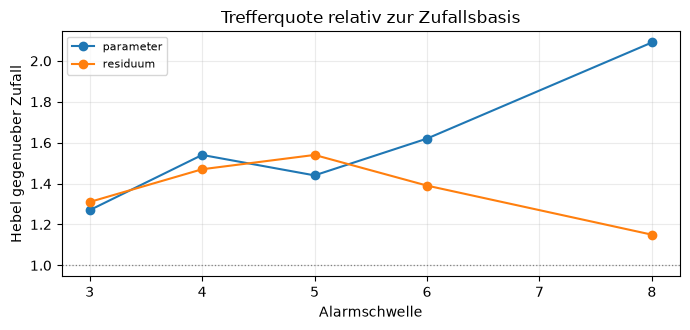

In [13]:
nur_schwelle = sweep[sweep["topk"] == 0]
fig, ax = plt.subplots(figsize=(7, 3.4))
for q, teil in nur_schwelle.groupby("quelle"):
    ax.plot(teil["schwelle"], teil["hebel"], marker="o", label=q)
ax.axhline(1.0, color="grey", ls=":", lw=0.9)
ax.set_xlabel("Alarmschwelle")
ax.set_ylabel("Hebel gegenueber Zufall")
ax.set_title("Trefferquote relativ zur Zufallsbasis")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

print("staerkster Alarm je Station:")
print(sweep[sweep["topk"] == 1].to_string(index=False))

- **Parameterkanal:** Hebel steigt mit der Schwelle von 1,3 auf rund 2,1, kleinstes p = 0,014. Bei 16 getesteten Einstellungen ist das aber nicht belastbar.
- **Residuenkanal:** verliert bei hohen Schwellen (Schwelle 8: Hebel 1,15, p = 0,46).
- **Nur der stärkste Alarm je Station:** Parameterkanal trifft 3 von 53, schlechter als Zufall. Residuenkanal 7 Treffer, auch Zufallsbereich.

Die größten Sprünge sind also meist keine Begehungen. Naheliegend wären Zählertausch oder der Wechsel der Messauflösung, geprüft ist das nicht.

## 7 Trifft der Monitor wenigstens die Begehungen mit Eingriff?

Nicht bei jeder Begehung wurde etwas verstellt. Das Protokoll hat Alt- und Neu-Werte für Heizzeit, Trinkwarmwasser und Sollwerte. Nur wo sich die unterscheiden, ist eine Änderung dokumentiert.

In [14]:
beg = lb.begehungen_mit_zaehler()
beg = beg[beg["meter"].notna() & beg["datum"].notna()].copy()
beg["meter"] = beg["meter"].astype(int)
beg = beg[beg["meter"].isin(beobachtet)]

PAARE = [("heizzeit_alt_von", "heizzeit_neu_von"),
         ("heizzeit_alt_bis", "heizzeit_neu_bis"),
         ("tww_alt_von", "tww_neu_von"),
         ("tww_alt_bis", "tww_neu_bis"),
         ("rw_soll_tag_alt", "rw_soll_tag_neu"),
         ("rw_soll_nacht_alt", "rw_soll_nacht_neu"),
         ("tww_soll_alt", "tww_soll_neu")]


def geaendert(zeile):
    for alt, neu in PAARE:
        a, n = zeile.get(alt), zeile.get(neu)
        if pd.isna(a) or pd.isna(n):
            continue
        if str(a).strip() != str(n).strip():
            return True
    return False


beg["eingriff"] = beg.apply(geaendert, axis=1)
print(beg["eingriff"].value_counts().to_string())

zeilen = []
for flag in (True, False):
    teil = beg[beg["eingriff"] == flag]
    t_split = {}
    for m, d in zip(teil["meter"], teil["datum"]):
        t_split.setdefault(int(m), []).append(d)
    z = (km.trefferquote(km.validiere(alarme, t_split))
         .merge(km.zufallsbasis(alarme, abdeckung, t_split),
                on=["quelle", "kennzahl"], how="left"))
    for _, r in z.iterrows():
        n, k, p = int(r["faelle"]), int(r["treffer"]), float(r["erwartete_quote"])
        zeilen.append({"eingriff": flag, "quelle": r["quelle"],
                       "faelle": n, "treffer": k,
                       "quote": round(k / n, 3) if n else np.nan,
                       "zufall": round(p, 3),
                       "hebel": round((k / n) / p, 2) if n and p else np.nan,
                       "p": round(float(stats.binomtest(
                           k, n, p, alternative="greater").pvalue), 4)})

print()
print(pd.DataFrame(zeilen).to_string(index=False))

eingriff
True     39
False    14

 eingriff    quelle  faelle  treffer  quote  zufall  hebel      p
     True parameter      39       17  0.436   0.383   1.14 0.3021
     True  residuum      39       15  0.385   0.281   1.37 0.1049
    False parameter      14        8  0.571   0.340   1.68 0.0644
    False  residuum      14        5  0.357   0.304   1.18 0.4279


Die Trennung funktioniert nicht, die Gruppe ohne dokumentierten Eingriff liegt sogar höher. Zwei mögliche Erklärungen:

- die Alarme sind überwiegend Rauschen
- die Alt-Neu-Spalten zeigen nicht, was wirklich gemacht wurde (mechanische Arbeiten stehen dort nicht). Dafür spricht, dass auch die Reparatur bei 68956351 dort fehlt.

## Zusammenfassung

**Belastbar:**

- Die Kennlinie funktioniert als stationseigenes Modell und lässt sich für alle 100 Stationen rechnen.
- Beim einzigen bekannten Fall (68956351) kommt der größte Ausschlag der ganzen Historie drei Tage nach der Reparatur.
- Das Sommerproblem der Fensterlogik ist behoben und per Test abgesichert.

**Schwach:**

- Über den Einzelfall hinaus: beide Kanäle ca. 30 % über Zufall bei rund 50 Begehungen, aber kein belastbarer p-Wert.
- Der stärkste Alarm je Station trifft schlechter als Zufall.
- Die Trennung nach dokumentiertem Eingriff dreht sich um.

**Eigentliches Problem: die Labels.**

- Die Alt-Neu-Spalten enthalten Sollwertänderungen, aber nicht alles, was an einer Station passiert.
- Notebook 15 kodiert deshalb die Freitexte. Damit trifft der Residuenkanal die mechanischen Eingriffe in 10 von 19 Fällen (0,526 gegen Zufallsbasis 0,287, p = 0,024), die übrigen 39 Fälle liegen auf Zufallsniveau.

**Fürs Team:**

- Die Schwellen sind gesetzt, nicht hergeleitet. Ab welchem Score fährt man hin?
- Knapp fünf Alarme je Station und Jahr: brauchbar oder zu viel?
- Stärkste Ausschläge gegen Zählertausch und Auflösungswechsel prüfen (Stammdaten nötig)

**Offen:**

- Wechsel der Messauflösung vor November 2022 ist nicht dokumentiert und trifft den Parameterkanal direkt
- Stillstand sieht der Monitor nicht (keine Punkte, kein Fit)
- Stationen, die schon immer falsch eingestellt sind, haben keine gesunde Referenz. Dafür braucht es weiter den Quervergleich.